In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import k_means
from sklearn.model_selection import (train_test_split,GridSearchCV)
from sklearn.preprocessing import (StandardScaler)
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

In [2]:
df=pd.read_csv("Mall_customers.csv")
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
print("Shape of the dataframe is ",df.shape)
print("-"*64)
print("Column names are\n",df.columns)
print("Information of the dataset")
print("-"*64)
df.info()

Shape of the dataframe is  (200, 5)
----------------------------------------------------------------
Column names are
 Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
Information of the dataset
----------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

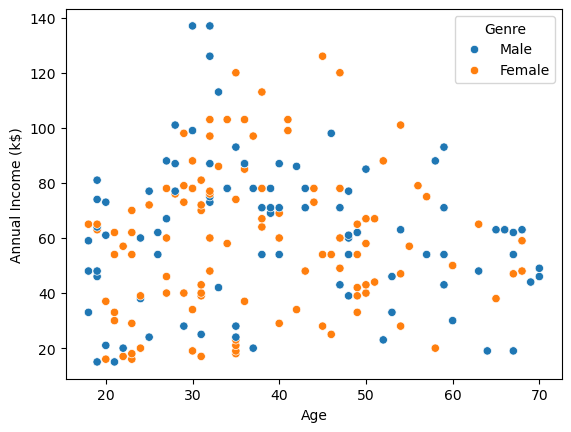

In [5]:
sns.scatterplot(x="Age",y="Annual Income (k$)",data=df,hue="Genre")

In [6]:
X = df[['Age', 'Spending Score (1-100)']]
X.head()

,Age,Spending Score (1-100)
0,19,39
1,21,81
2,20,6
3,23,77
4,31,40


In [7]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [12]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

In [11]:
wcss

[400.0,
 189.38749033992428,
 124.32628617921527,
 89.7652167658615,
 71.2955659221944,
 53.128438356294,
 45.907104565678466,
 39.1851961213981,
 34.168841096196275,
 28.861661066694086,
 25.485902407346252,
 23.565994253292764,
 21.517496173978326,
 19.415173439788227]

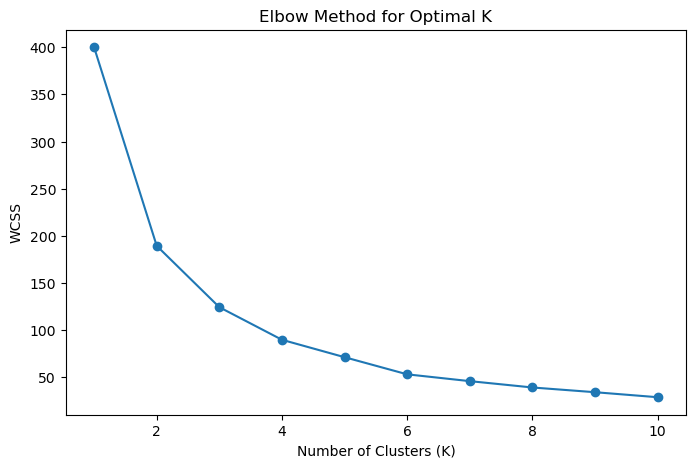

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [14]:
kmeans = KMeans(
n_clusters=5,
random_state=42,
n_init=10
)

In [15]:
kmeans.fit(X_scaled)

,n_clusters,5
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [17]:
clusters = kmeans.fit_predict(X_scaled)
df['Cluster']= clusters
df.head()
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,1
2,3,Female,20,16,6,2
3,4,Female,23,16,77,1
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,3
197,198,Male,32,126,74,1
198,199,Male,32,137,18,3


In [22]:
silhouette = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", silhouette)

Silhouette Score: 0.4475485887887892


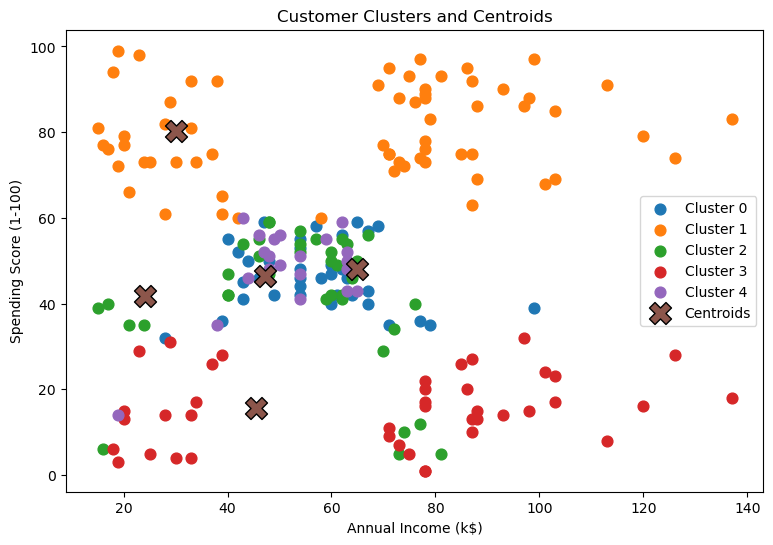

In [19]:
centroids_original= scaler.inverse_transform(kmeans.cluster_centers_)
plt.figure(figsize=(9, 6))
for cluster in sorted(df['Cluster'].unique()):
    cluster_data= df[df['Cluster']== cluster]
    plt.scatter(
    cluster_data['Annual Income (k$)'],
    cluster_data['Spending Score (1-100)'],
    label=f'Cluster {cluster}'
    ,
    s=60
    )
plt.scatter(
centroids_original[:, 0],
centroids_original[:, 1],
marker='X',
s=250,
edgecolors='black',
label='Centroids'
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters and Centroids")
plt.legend()
plt.show()

In [61]:
def silhouette_scorer(estimator, X, y=None):
    clusters = estimator.predict(X)
    return silhouette_score(X, clusters)
k_means=KMeans()
from sklearn.pipeline import Pipeline
pipeline=Pipeline([
    ('scaler',StandardScaler()),
    ('model',k_means)
])
param={
    "model__n_clusters":np.arange(5,10),
    "model__n_init":[15],
    "model__random_state":[42]
}
grid=GridSearchCV(
    estimator=pipeline,
    param_grid=param,
    scoring=silhouette_scorer
)

In [62]:
grid.fit(X)

,estimator,"Pipeline(step...', KMeans())])"
,param_grid,"{'model__n_clusters': array([5, 6, 7, 8, 9]), 'model__n_init': [15], 'model__random_state': [42]}"
,scoring,<function sil...t 0x317256b60>
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [ ]:
grid.best_score_

np.float64(0.4000342652932007)

In [56]:
clusters = grid.best_estimator_.fit_predict(X)
df['Cluster']= clusters
df.head()
grid.best_estimator_.named_steps['model']

,n_clusters,np.int64(3)
,init,'k-means++'
,n_init,15
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


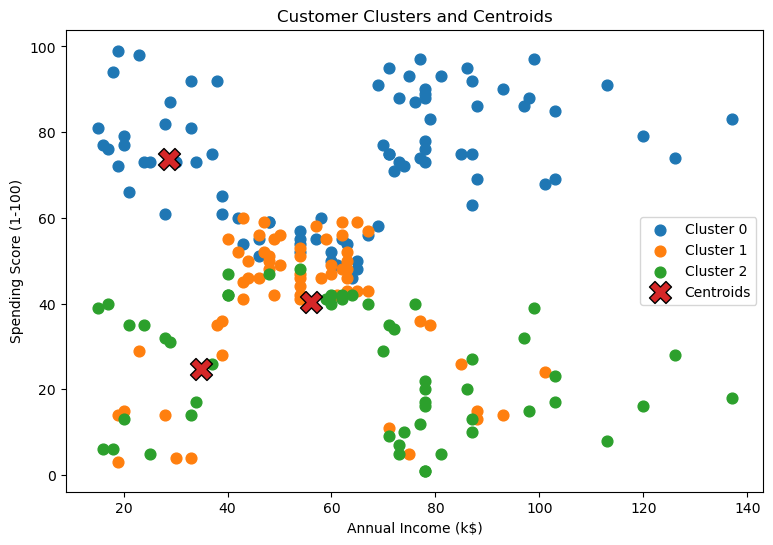

In [57]:
centroids_original= scaler.inverse_transform(grid.best_estimator_.named_steps['model'].cluster_centers_)
plt.figure(figsize=(9, 6))
for cluster in sorted(df['Cluster'].unique()):
    cluster_data= df[df['Cluster']== cluster]
    plt.scatter(
    cluster_data['Annual Income (k$)'],
    cluster_data['Spending Score (1-100)'],
    label=f'Cluster {cluster}'
    ,
    s=60
    )
plt.scatter(
centroids_original[:, 0],
centroids_original[:, 1],
marker='X',
s=250,
edgecolors='black',
label='Centroids'
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters and Centroids")
plt.legend()
plt.show()

,n_clusters,np.int64(2)
,init,'k-means++'
,n_init,np.int64(8)
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'
